In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

melakukan import libary yang di gunakan

In [17]:
def filter(img, size, mode):
    height, width = img.shape
    pad = size // 2
    padded = np.pad(img, pad, mode='edge')
    canvas = np.zeros_like(img, dtype=np.uint8)
    match mode:
        case 'mean':
            area = size * size
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    total = 0
                    for r in range(size):
                        for c in range(size):
                            total += int(region[r, c])
                    canvas[i, j] = total // area

        case 'median':
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    values = [0] * (size * size)
                    for r in range(size):
                        for c in range(size):
                            values[r * size + c] = int(region[r, c])

                    n = size * size
                    for x in range(n - 1):
                        for y in range(n - x - 1):
                            if values[y] > values[y + 1]:
                                values[y], values[y + 1] = values[y + 1], values[y]

                    canvas[i, j] = values[n // 2]

        case 'modus':
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    values = region.ravel()
                    count = {}
                    for val in values:
                        if val in count:
                            count[val] += 1
                        else:
                            count[val] = 1

                    max_count = 0
                    mode_val = 0
                    for val, freq in count.items():
                        if freq > max_count:
                            max_count = freq
                            mode_val = val
                    canvas[i, j] = mode_val

    return canvas

Fungsi filter di atas digunakan untuk melakukan penyaringan citra keabuan menggunakan tiga metode rata-rata (mean), nilai tengah (median), dan modus (modus). Pada awal proses, gambar diberikan garis tepi tambahan menggunakan np.pad dengan replikasi piksel terluar (mode='edge') agar operasi matriks tetangga (jendela filter) tidak melewati batas ukuran asli gambar. Selanjutnya, sebuah matriks kosong bernama canvas disiapkan dengan ukuran yang sama seperti citra asli untuk menampung hasil akhir pemrosesan piksel demi piksel.

In [3]:
kernelSmoothing = np.array([
    [1/10, 1/10, 1/10],
    [1/10, 1/5,  1/10],
    [1/10, 1/10, 1/10]
])

kernelSharpening = np.array([
    [1/9, 1/9, 1/9],
    [1/9, 8/9, 1/9],
    [1/9, 1/9, 1/9]
])

sobelX = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

sobelY = np.array([
    [ 1,  2,  1],
    [ 0,  0,  0],
    [-1, -2, -1]
], dtype=np.float32)

prewittX = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
], dtype=np.float32)

prewittY = np.array([
    [ 1,  1,  1],
    [ 0,  0,  0],
    [-1, -1, -1]
], dtype=np.float32)

robertsX = np.array([
    [1, 0],
    [0, -1]
], dtype=np.float32)

robertsY = np.array([
    [0, 1],
    [-1, 0]
], dtype=np.float32)

Kode di atas mendefinisikan berbagai matriks filter (kernel) berukuran 2x2 dan 3x3 berbasis NumPy untuk proses konvolusi citra digital. Setiap kernel dirancang khusus untuk memanipulasi nilai piksel tetangga guna mencapai efek visual tertentu atau mendeteksi fitur spasial pada gambar.

In [9]:
def convolution(img, kernel):
    size = kernel.shape[0]
    pad_size = size // 2
    padded = np.pad(img, pad_size, mode='constant')
    canvas = np.zeros_like(img).astype(np.float32)
    height, width = img.shape

    for i in range(height):
        for j in range(width):
            region = padded[i:i+size, j:j+size]
            canvas[i, j] = np.sum(region * kernel)

    return canvas

Fungsi convolution di atas melakukan operasi konvolusi 2D secara manual pada citra keabuan menggunakan kernel yang ada di shell sebelumnya yang dimasukkan sebagai parameter.

In [10]:
def tepi(img, kernelx, kernely):
    gx = convolution(img, kernelx)
    gy = convolution(img, kernely)

    canvas = np.zeros_like(img, dtype=np.float32)
    canvas = np.abs(gx) + np.abs(gy)
    canvas = canvas * 255.0 / np.max(canvas)

    return np.clip(canvas, 0, 255).astype(np.uint8)

Fungsi tepi di atas digunakan untuk mendeteksi tepi objek pada citra dengan menggabungkan hasil ekstraksi fitur gradien horizontal (kernel x yang sudah ada didefinisikan di shell atas atas sebelumnya) dan vertikal (kernel y yang sudah ada didefinisikan di shell atas atas sebelumnya).

In [26]:
def normalisasi(citra):
    min_val = int(citra[0,0])
    max_val = int(citra[0,0])
    for i in range(citra.shape[0]):
        for j in range(citra.shape[1]):
            if citra[i,j] < min_val: min_val = int(citra[i,j])
            if citra[i,j] > max_val: max_val = int(citra[i,j])
    
    hasil = np.zeros(citra.shape, dtype=np.uint8)
    for i in range(citra.shape[0]):
        for j in range(citra.shape[1]):
            hasil[i,j] = int((int(citra[i,j]) - min_val) / (max_val - min_val) * 255)
    return hasil

Fungsi normalisasi di atas digunakan untuk melakukan peregangan kontras secara manual pada sebuah citra digital. Proses ini mengubah rentang nilai intensitas piksel asli yang sempit atau tidak standar menjadi rentang penuh 0 sampai 255 agar gambar terlihat lebih jelas dan seimbang.

In [28]:
def threshold(img, thresh):

    height, width = img.shape

    canvas = np.zeros_like(img)

    for i in range(height):
        for j in range(width):

            if img[i, j] > thresh:
                canvas[i, j] = 255
            else:
                canvas[i, j] = 0

    return canvas

Fungsi threshold di atas digunakan untuk melakukan operasi pengambangan (thresholding) biner secara manual pada sebuah citra keabuan. Proses ini bertujuan untuk memisahkan objek utama dari latar belakang dengan cara mengubah gambar menjadi citra hitam-putih.

### cctv

In [19]:
img = cv2.imread("backup.jpg")
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

hasil_mean = filter(img_gray, 3, 'mean')
hasil_mean9 = filter(img_gray, 9, 'mean')

hasil_median = filter(img_gray, 3, 'median')
hasil_median9 = filter(img_gray, 9, 'median')

hasil_modus = filter(img_gray, 3, 'modus')
hasil_modus9 = filter(img_gray, 9, 'modus')

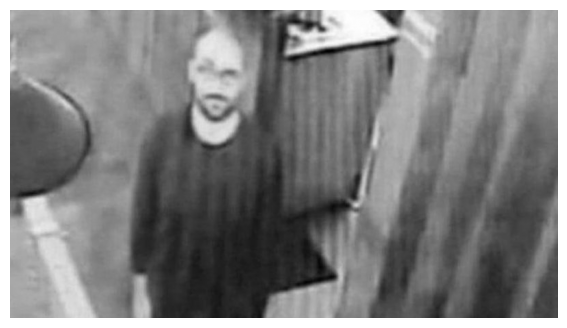

In [25]:
plt.figure(figsize=(12,4))
plt.imshow(img_gray, cmap='gray')
plt.axis('off')
plt.show()

ini foto backup pada soal, foto ini sudah di grayscale kan agar dapat diproses untuk

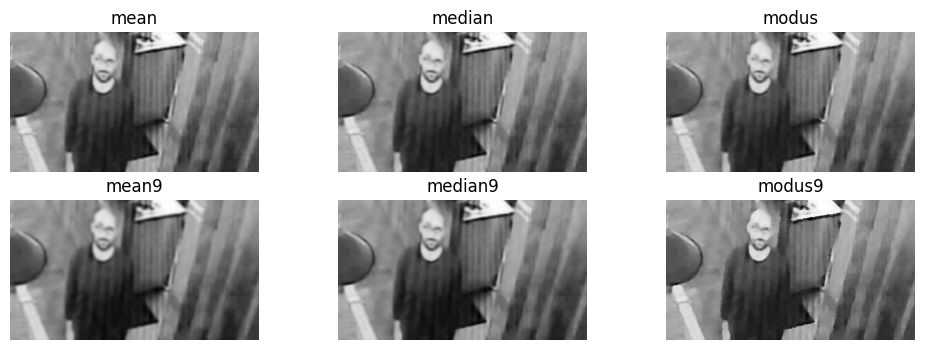

In [20]:
plt.figure(figsize=(12,4))

plt.subplot(2,3,1)
plt.imshow(hasil_mean, cmap='gray')
plt.title('mean')
plt.axis('off')

plt.subplot(2,3,2)
plt.imshow(hasil_median, cmap='gray')
plt.title('median')
plt.axis('off')

plt.subplot(2,3,3)
plt.imshow(hasil_modus, cmap='gray')
plt.title('modus')
plt.axis('off')

plt.subplot(2,3,4)
plt.imshow(hasil_mean9, cmap='gray')
plt.title('mean9')
plt.axis('off')

plt.subplot(2,3,5)
plt.imshow(hasil_median9, cmap='gray')
plt.title('median9')
plt.axis('off')

plt.subplot(2,3,6)
plt.imshow(hasil_modus9, cmap='gray')
plt.title('modus9')
plt.axis('off')

plt.show()

keenam gambar di atas merupakan hasil filter dengan ketiga metode yang ada yaitu mean, median dan modus dari gambar backup yang sudah di grayscale. pada gambar tersebut tidak terlihat perbedaan dari hasil penggunaan filter dengan ketiga metode tersebut. kalau menurut saya karna gambarnya sudah halus karena ketiga metode itu untuk menghilangkan noise seperti titik titik di piksel yang brutal.

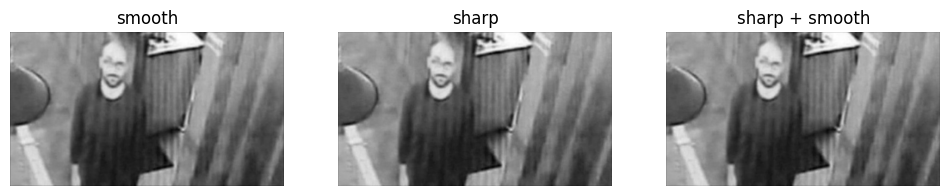

In [21]:
hasil_smooth = convolution(img_gray.astype(np.float32), kernelSmoothing)
hasil_sharp  = convolution(img_gray.astype(np.float32), kernelSharpening)
hasil_sharp_smooth = hasil_smooth + hasil_sharp
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(hasil_smooth, cmap='gray')
plt.title('smooth')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(hasil_sharp, cmap='gray')
plt.title('sharp')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(hasil_sharp_smooth, cmap='gray')
plt.title('sharp + smooth')
plt.axis('off')

plt.show()

pada gambar di atas adalah memperhalus, mempertajam dan mengkombinasi kedua metode tersebut. Dari gambar diatas tidak terlihat perbedaan yang signifikan(tidak terlihat) bisa saja disebabkan karena gambarnya yang resolusinya rendah dan blur dari sananya.

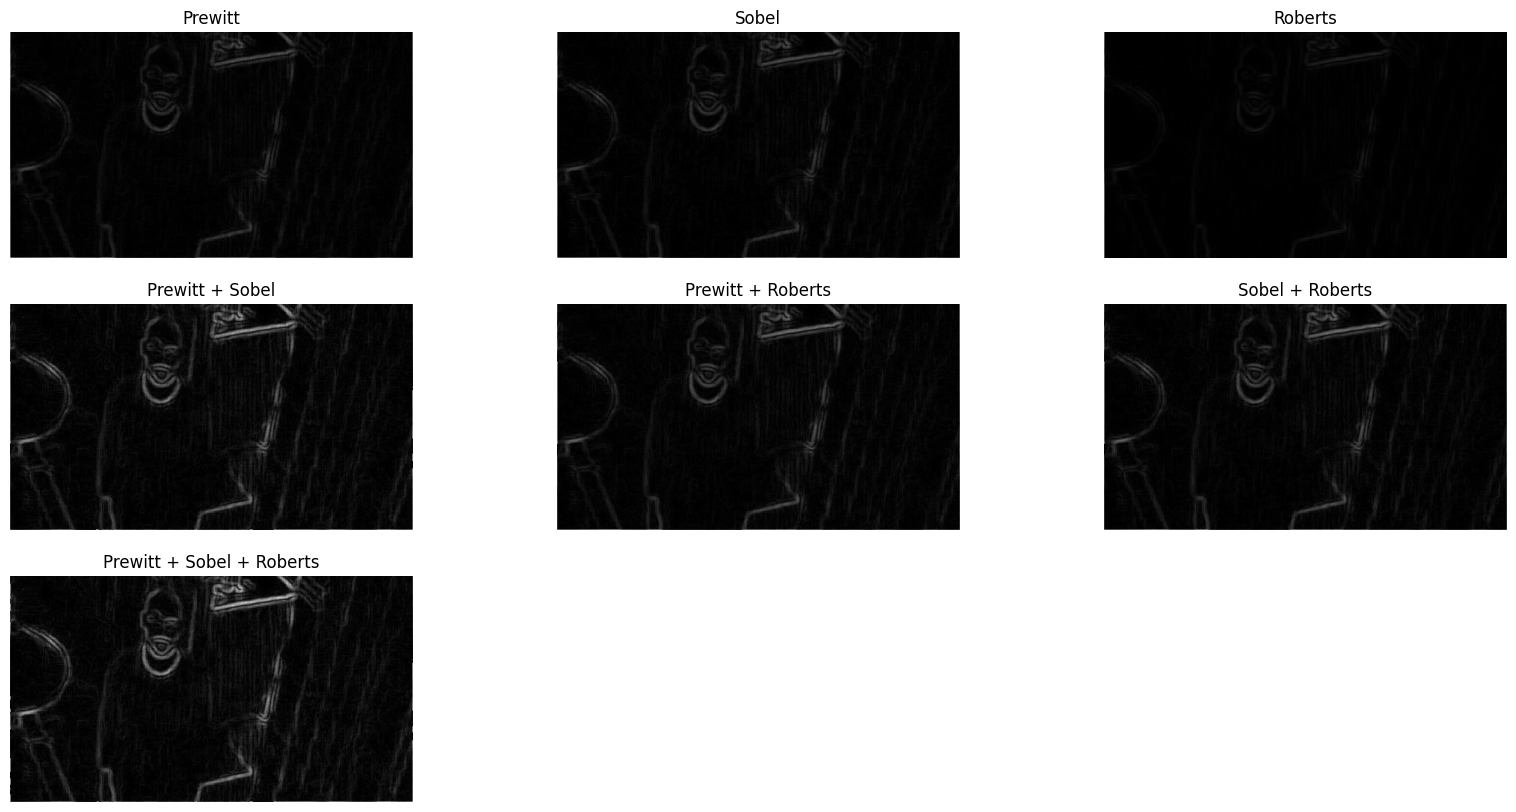

In [27]:
prewit_cctv = tepi(img_gray, prewittX, prewittY)
sobel_cctv = tepi(img_gray, sobelX, sobelY)
robert_cctv = tepi(img_gray, robertsX, robertsY)

prewit_sobel_cctv = normalisasi(prewit_cctv + sobel_cctv)
prewit_robert_cctv = normalisasi(prewit_cctv + robert_cctv)
sobel_robert_cctv = normalisasi(sobel_cctv + robert_cctv)
sobel_prewit_robert = normalisasi(sobel_cctv + prewit_cctv + robert_cctv)

plt.figure(figsize=(20, 10))

plt.subplot(3, 3, 1)
plt.imshow(prewit_cctv, cmap='gray')
plt.title("Prewitt")
plt.axis('off')

plt.subplot(3, 3, 2)
plt.imshow(sobel_cctv, cmap='gray')
plt.title("Sobel")
plt.axis('off')

plt.subplot(3, 3, 3)
plt.imshow(robert_cctv, cmap='gray')
plt.title("Roberts")
plt.axis('off')

plt.subplot(3, 3, 4)
plt.imshow(prewit_sobel_cctv, cmap='gray')
plt.title("Prewitt + Sobel")
plt.axis('off')

plt.subplot(3, 3, 5)
plt.imshow(prewit_robert_cctv, cmap='gray')
plt.title("Prewitt + Roberts")
plt.axis('off')

plt.subplot(3, 3, 6)
plt.imshow(sobel_robert_cctv, cmap='gray')
plt.title("Sobel + Roberts")
plt.axis('off')

plt.subplot(3, 3, 7)
plt.imshow(sobel_prewit_robert, cmap='gray')
plt.title("Prewitt + Sobel + Roberts")
plt.axis('off')

plt.show()

pada gambar di atas mendeteksi tepi dengan menggunakan operator sobel memiliki keakuratan yang lebih abik dari pada dua operator lainnya, untuk prewit hampis seperti sobel tetapi kurang akurat dikit, lalu untuk robert yang paling tidak akurat untu deteksi tepi.

kombinasi operator prewit dan sobet bisa dibilang kombinasi antara 2 operatoor yang paling bagus, lalu semakin banyak operator yang di gunakan semakin akurat hasil deteksi tepinya.

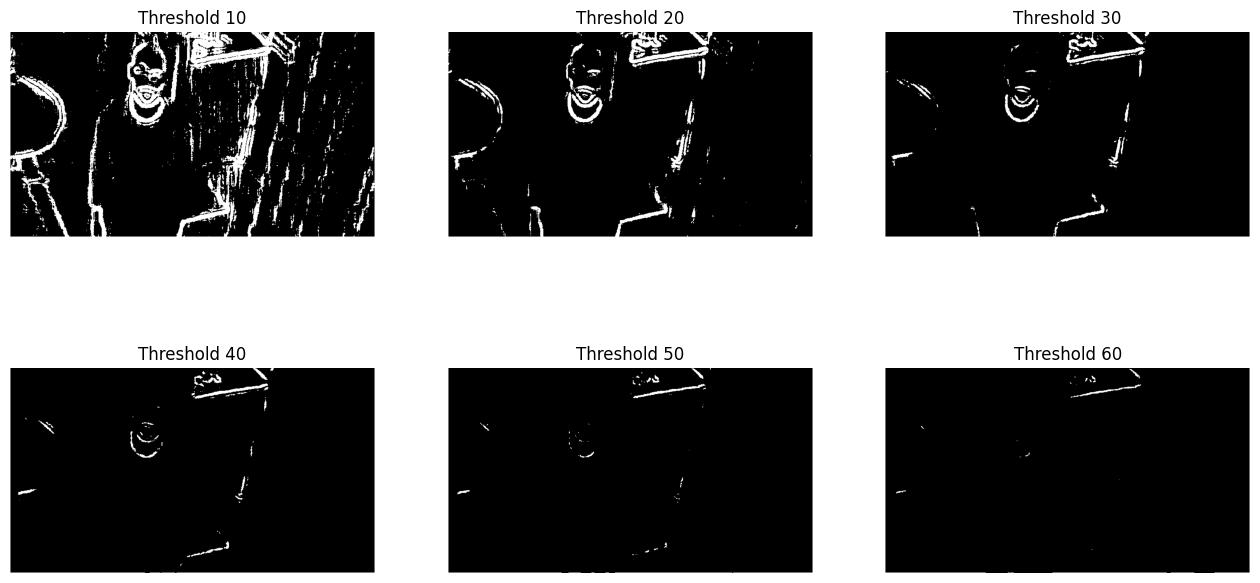

In [31]:
tcctv_10 = threshold(prewit_cctv, 10)
tcctv_20 = threshold(prewit_cctv, 20)
tcctv_30 = threshold(prewit_cctv, 30)
tcctv_40 = threshold(prewit_cctv, 40)
tcctv_50 = threshold(prewit_cctv, 50)
tcctv_60 = threshold(prewit_cctv, 60)

plt.figure(figsize=(16, 8))

plt.subplot(2, 3, 1)
plt.imshow(tcctv_10, cmap='gray')
plt.title("Threshold 10")
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(tcctv_20, cmap='gray')
plt.title("Threshold 20")
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(tcctv_30, cmap='gray')
plt.title("Threshold 30")
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(tcctv_40, cmap='gray')
plt.title("Threshold 40")
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(tcctv_50, cmap='gray')
plt.title("Threshold 50")
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(tcctv_60, cmap='gray')
plt.title("Threshold 60")
plt.axis('off')

plt.show()

gambar yang saya thresholding itu adalah gambar hasil dari pendeteksi tepi dengan operator prewit, threshold ini berfungsi uuntuk memperjelas garis tepi dari gambar nya. pada gambar di atas yang bisa di simpulkan adalah semakin besar angka thresholdnya semakin tidak terlihat garis tepinya.

In [42]:
def highlight_cctv(img_asli, mask_biner):
    height, width = mask_biner.shape[:2]

    # 1. Cari garis tepi dari mask biner
    # Piksel dianggap tepi jika dia putih (255) tapi punya tetangga yang hitam (0)
    padded = np.pad(mask_biner, ((1, 1), (1, 1)), mode='constant', constant_values=0)
    edges = np.zeros_like(mask_biner)

    for i in range(height):
        for j in range(width):
            if padded[i+1, j+1] == 255:
                atas  = padded[i,   j+1]
                bawah = padded[i+2, j+1]
                kiri  = padded[i+1, j]
                kanan = padded[i+1, j+2]
                if atas == 0 or bawah == 0 or kiri == 0 or kanan == 0:
                    edges[i, j] = 255

    # 2. Buat canvas dari gambar asli
    if len(img_asli.shape) == 2:
        # Grayscale → jadikan 3 channel
        canvas = np.stack([img_asli, img_asli, img_asli], axis=-1).astype(np.float32)
    else:
        canvas = img_asli.copy().astype(np.float32)

    warna_kuning = np.array([255, 220, 0], dtype=np.float32)

    # 3. Overlay kuning pada area siluet + garis tepi solid kuning
    for i in range(height):
        for j in range(width):
            if mask_biner[i, j] == 255:
                # Tint kuning 40% pada area dalam siluet
                canvas[i, j] = canvas[i, j] * 0.6 + warna_kuning * 0.4
            if edges[i, j] == 255:
                # Garis tepi kuning solid penuh
                canvas[i, j] = warna_kuning

    return np.clip(canvas, 0, 255).astype(np.uint8)

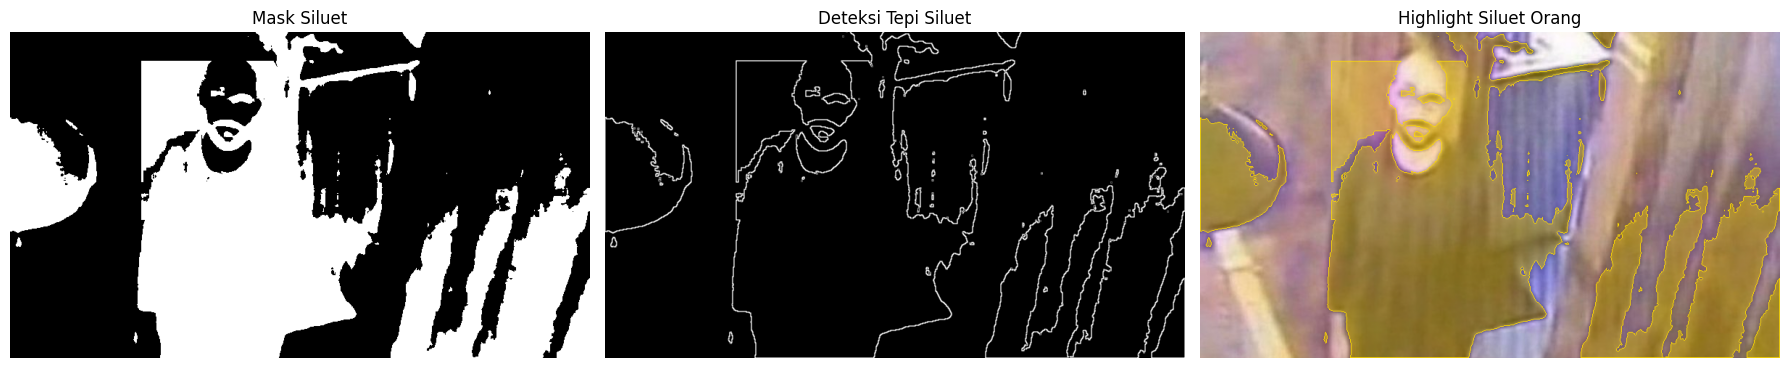

In [43]:
def highlight_siluet_orang(img_path):
    # Load gambar
    img_bgr = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    
    h, w = img_gray.shape

    # --- Step 1: Buat mask siluet orang berdasarkan warna piksel ---
    # Orang: baju gelap (gray < 105) ATAU kulit muka (R dominan, area wajah)
    # Exclude: area sangat terang (gray > 195) → background putih/papan
    mask = np.zeros((h, w), dtype=np.uint8)
    for i in range(h):
        for j in range(w):
            r = int(img_rgb[i, j, 0])
            g = int(img_rgb[i, j, 1])
            b = int(img_rgb[i, j, 2])
            gv = int(img_gray[i, j])

            if gv > 195:  # skip background sangat terang
                continue

            is_dark_clothes = gv < 105  # baju gelap/hitam/ungu
            is_skin = (r > b + 10) and (80 < gv < 175) and (180 < j < 520) and (40 < i < 260)

            if is_dark_clothes or is_skin:
                mask[i, j] = 255

    # --- Step 2: Deteksi tepi siluet pakai fungsi tepi() yang sudah ada ---
    tepi_siluet = tepi(mask.astype(np.float32), sobelX, sobelY)

    # --- Step 3: Highlight kuning pakai fungsi highlight_cctv() yang sudah ada ---
    hasil_highlight = highlight_cctv(img_rgb, mask)

    # --- Tampilkan 3 panel ---
    plt.figure(figsize=(18, 6))

    plt.subplot(1, 3, 1)
    plt.imshow(mask, cmap='gray')
    plt.title('Mask Siluet')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(tepi_siluet, cmap='gray')
    plt.title('Deteksi Tepi Siluet')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(hasil_highlight)
    plt.title('Highlight Siluet Orang')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

# Panggil
highlight_siluet_orang('backup.jpg')

bagian ini tidak mendekati seperti pada modul. fungsi melakukan penyaringan warna secara manual menggunakan perulangan untuk memisahkan objek orang dari latar belakangnya. Piksel akan dianggap sebagai bagian dari tubuh orang jika memiliki warna baju yang gelap(warna lain yang lebih terang ngga) koordinat tertentu, sementara area latar belakang yang sangat terang sengaja diabaikan.

### PAS FOTO DAPID

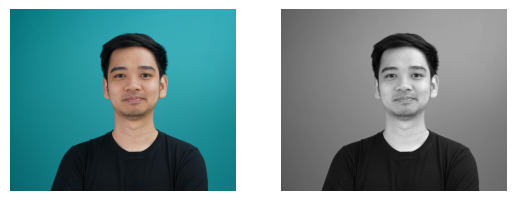

In [37]:
david = cv2.imread('david.jpg')
david_gray = cv2.cvtColor(david, cv2.COLOR_BGR2GRAY)
david_warna = cv2.cvtColor(david, cv2.COLOR_BGR2RGB)
plt.subplot(1, 2, 1)
plt.imshow(david_warna)
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(david_gray, cmap='gray')
plt.axis('off')
plt.show()

gambar david yang bisasa dan yang sudah di grayscale

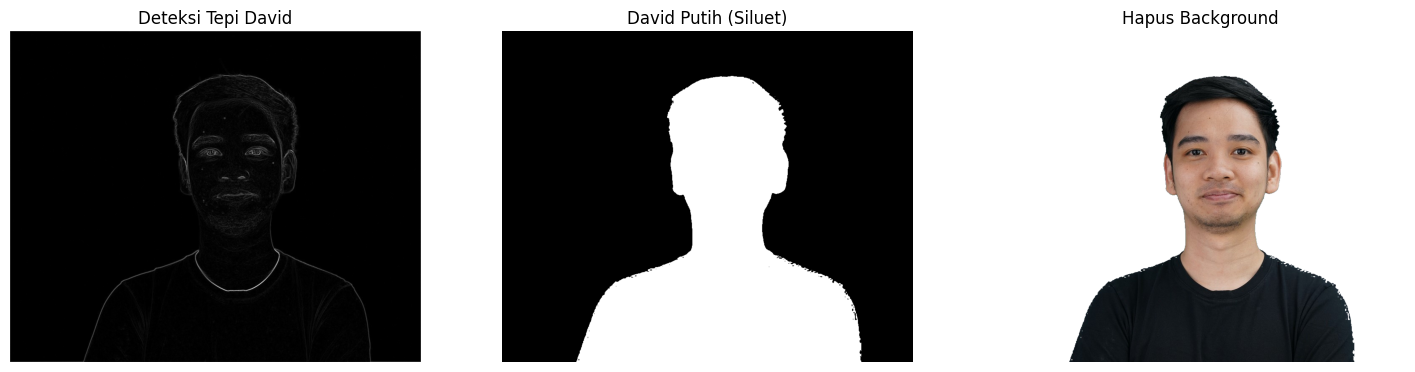

In [38]:
david_tepi = tepi(david_gray, sobelX, sobelY)

height, width, _ = david_warna.shape

david_aja = np.zeros_like(david_warna)
david_putih = np.zeros_like(david_warna)

for i in range(height):
    for j in range(width):
        r = int(david_warna[i, j, 0])
        g = int(david_warna[i, j, 1])
        b = int(david_warna[i, j, 2])

        if g > (r + 15) and b > (r + 15):
            david_aja[i, j] = [255, 255, 255]
        else:
            david_aja[i, j] = [r, g, b]

        if not (g > (r + 15) and b > (r + 15)):
            david_putih[i, j] = [255, 255, 255]
        else:
            david_putih[i, j] = [0, 0, 0]

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(david_tepi, cmap='gray')
plt.title('Deteksi Tepi David')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(david_putih)
plt.title('David Putih (Siluet)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(david_aja)
plt.title('Hapus Background')
plt.axis('off')

plt.show()

Kode di atas melakukan tiga teknik secara bersamaan untuk memisahkan objek David dari latar belakangnya. Pada gambar pertama, fungsi tepi berhasil mengekstraksi struktur fisik objek secara tajam memanfaatkan operator Sobel. gambar kedua dan ketiga menerapkan teknik pengambangan warna berbasis aturan komponen RGB, di mana piksel latar belakang yang didominasi warna hijau dan biru diisolasi secara penuh. Aturan ini berhasil menciptakan mask siluet hitam-putih pada gambar david_putih, sekaligus menghapus latar belakang asli menjadi putih bersih pada gambar david_aja dengan tetap mempertahankan warna muka david.

### Kesimpulan

perbaikan kualitas citra dan deteksi tepi sangat penting untuk membaca sebuah gambar dengan lebih mudah. Perbaikan kualitas citra, seperti menghilangkan bintik rusak (noise) dan mencerahkan warna yang pudar, berguna untuk membersihkan gambar agar terlihat lebih jelas. Setelah gambarnya bersih, teknik deteksi tepi bertugas untuk mencari garis luar atau bentuk asli dari objek di dalam gambar tersebut. Ketika kedua cara ini digabungkan, kita bisa dengan mudah memisahkan objek utama dari latar belakangnya, seperti yang dilakukan pada eksperimen gambar David.